In [38]:
import torch
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns


PARTE 2: PREPARACIÓN DATASET

In [39]:
# transformaciones para entrenamiento

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transformaciones para validación y test
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PARTE 3: CARGAR EL DATASET

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/DATA_AAA/oddData'

# Check if the directory exists
if not os.path.exists(ruta):
    print(f"Error: The directory '{ruta}' does not exist.")
    print("Please make sure you have mounted Google Drive and that the path to your 'fotos_AAA' folder is correct.")
    # Initialize files as an empty list to prevent further errors if the directory is not found
    files = []
else:
    files = os.listdir(ruta)
    print(f"Total imágenes: {len(files)}'")
    print('Primeros 10: ')
    for f in files[:10]:
        print(f)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total imágenes: 3'
Primeros 10: 
val
train
test


In [41]:
from torchvision import datasets
from torch.utils.data import DataLoader


class ImageFolder(datasets.ImageFolder):
  def __getitem__(self, index):
    try:
      return super(ImageFolder, self).__getitem__(index)
    except:
      return self.__getitem__(index + 1)

# Load pre-split datasets from subfolders
train_dataset = ImageFolder(f"{ruta}/train", transform=transform_train)
val_dataset = ImageFolder(f"{ruta}/val", transform=transform_val)
test_dataset = ImageFolder(f"{ruta}/test", transform=transform_val)

print(f"Total imágenes en train: {len(train_dataset)}")
print(f"Total imágenes en val: {len(val_dataset)}")
print(f"Total imágenes en test: {len(test_dataset)}")

classes = train_dataset.classes # Define 'classes' variable from one of the datasets
print(f"Clases: {classes}")



Total imágenes en train: 377
Total imágenes en val: 78
Total imágenes en test: 89
Clases: ['Cups', 'Forks', 'Glasses', 'Knives', 'Plates', 'Spoons']


PARTE 4: CARGAR DATOS

In [42]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")


Batches en train: 24
Batches en val: 5
Batches en test: 6


PARTE 5: ARQUITECTURA CNN

In [43]:
import torch.nn as nn

class BaselineCNN(nn.Module):
  def __init__(self, num_classes=6, dropout_rate=0.5):
    super(BaselineCNN, self).__init__()


    # extracción características

    # bloque 1 : 3 canales RGB --> 32 filtros

    self.bloque1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )

    # bloque 2 : 32 filtros --> 64

    self.bloque2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )

    # bloque 3 : 64 filtros -> 128 filtros

    self.bloque3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(dropout_rate)
    )


    # clasificación

    self.clasificador = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.bloque1(x)
    x = self.bloque2(x)
    x = self.bloque3(x)
    x = self.clasificador(x)
    return x

In [44]:
modelo = BaselineCNN(num_classes=6, dropout_rate=0.5)
print(modelo)

BaselineCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=F

In [45]:
# vamos a probar que la red funciona con el tamaño de la imágenes

imagen_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
  salida = modelo(imagen_prueba)

print(imagen_prueba.shape)
print(salida.shape)
print(classes)

torch.Size([1, 3, 224, 224])
torch.Size([1, 6])
['Cups', 'Forks', 'Glasses', 'Knives', 'Plates', 'Spoons']


PARTE 6: ENTRENAMIENTO

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)

criterio = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
epochs = 20

hist_loss_train = []
hist_acc_train = [] # Nueva lista para la precisión de entrenamiento
hist_loss_val = []  # Nueva lista para la pérdida de validación
hist_acc_val = []

for epoch in range(epochs):

  # ENTRNAMIENTO

  modelo.train()
  loss_total_train = 0
  correctas_train = 0 # Para precisión de entrenamiento
  total_train = 0     # Para precisión de entrenamiento

  for imagenes, etiquetas in train_loader:
    imagenes = imagenes.to(device)
    etiquetas = etiquetas.to(device)

    optimizer.zero_grad() # resetea gradientes
    salida = modelo(imagenes) # forward pass
    loss = criterio(salida, etiquetas) # calcula error
    loss.backward() # backward pass
    optimizer.step() # actualizar pesos

    loss_total_train += loss.item()

    # Calcular precisión en entrenamiento
    _, predicciones_train = torch.max(salida, 1)
    correctas_train += (predicciones_train == etiquetas).sum().item()
    total_train += etiquetas.size(0)

  loss_medio_train = loss_total_train / len(train_loader)
  acc_train = correctas_train / total_train


  # fase de validación

  modelo.eval()
  correctas_val = 0
  total_val = 0
  loss_total_val = 0 # Para pérdida de validación

  with torch.no_grad():
    for imagenes, etiquetas in val_loader:
      imagenes = imagenes.to(device)
      etiquetas = etiquetas.to(device)
      salida = modelo(imagenes)
      loss_val = criterio(salida, etiquetas) # Calcula la pérdida de validación
      loss_total_val += loss_val.item()

      _, predicciones_val = torch.max(salida, 1)
      correctas_val += (predicciones_val == etiquetas).sum().item()
      total_val += etiquetas.size(0)

  loss_medio_val = loss_total_val / len(val_loader)
  acc_val = correctas_val / total_val

  hist_loss_train.append(loss_medio_train)
  hist_acc_train.append(acc_train) # Añadir precisión de entrenamiento
  hist_loss_val.append(loss_medio_val) # Añadir pérdida de validación
  hist_acc_val.append(acc_val)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Loss train: {loss_medio_train:.4f} | Acc train: {acc_train:.4f}")
  print(f"Loss val:   {loss_medio_val:.4f} | Acc val:   {acc_val:.4f}")


Epoch: 1/20 | Loss: 22.5418 | Acc: 0.3718 | F1: 0.2635
Epoch: 2/20 | Loss: 3.3154 | Acc: 0.3974 | F1: 0.3608
Epoch: 3/20 | Loss: 1.6136 | Acc: 0.3205 | F1: 0.2675
Epoch: 4/20 | Loss: 1.5600 | Acc: 0.3846 | F1: 0.3675
Epoch: 5/20 | Loss: 1.4823 | Acc: 0.4487 | F1: 0.4143
Epoch: 6/20 | Loss: 1.4187 | Acc: 0.4487 | F1: 0.3978
Epoch: 7/20 | Loss: 1.3979 | Acc: 0.4231 | F1: 0.3800
Epoch: 8/20 | Loss: 1.3658 | Acc: 0.4359 | F1: 0.4236
Epoch: 9/20 | Loss: 1.3653 | Acc: 0.4103 | F1: 0.3553
Epoch: 10/20 | Loss: 1.2608 | Acc: 0.5128 | F1: 0.4749
Epoch: 11/20 | Loss: 1.3219 | Acc: 0.4359 | F1: 0.3775
Epoch: 12/20 | Loss: 1.2149 | Acc: 0.4744 | F1: 0.4504
Epoch: 13/20 | Loss: 1.1659 | Acc: 0.4359 | F1: 0.3748
Epoch: 14/20 | Loss: 1.2218 | Acc: 0.4744 | F1: 0.4098
Epoch: 15/20 | Loss: 1.2070 | Acc: 0.4744 | F1: 0.4607
Epoch: 16/20 | Loss: 1.2321 | Acc: 0.4744 | F1: 0.4645
Epoch: 17/20 | Loss: 1.2527 | Acc: 0.4231 | F1: 0.3679
Epoch: 18/20 | Loss: 1.0950 | Acc: 0.4744 | F1: 0.4229
Epoch: 19/20 | Los

In [47]:

# EVALUACIÓN FINAL EN TEST SET
print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET")
print("="*60 + "\n")

modelo.eval()
correctas_test = 0
total_test = 0
todas_predicciones_test = []
todas_etiquetas_test = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salida = modelo(imagenes)
        _, predicciones = torch.max(salida, 1)

        correctas_test += (predicciones == etiquetas).sum().item()
        total_test += etiquetas.size(0)

        todas_predicciones_test.extend(predicciones.cpu().numpy())
        todas_etiquetas_test.extend(etiquetas.cpu().numpy())

# Calcular métricas finales
acc_test = correctas_test / total_test
f1_test = f1_score(todas_etiquetas_test, todas_predicciones_test, average='macro')

print(f"Test Accuracy:     {acc_test:.4f}")
print(f"Test Macro F1-Score: {f1_test:.4f}")

# Classification Report detallado
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(todas_etiquetas_test, todas_predicciones_test,
                          target_names=classes, digits=4))

print("\n✓ Evaluación en test completada")


EVALUACIÓN EN TEST SET

Test Accuracy:     0.5393
Test Macro F1-Score: 0.5301

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        Cups     0.6000    0.3750    0.4615        16
       Forks     0.3846    0.5000    0.4348        10
     Glasses     0.5000    0.3750    0.4286        16
      Knives     0.6190    0.8125    0.7027        16
      Plates     0.8182    0.5625    0.6667        16
      Spoons     0.4091    0.6000    0.4865        15

    accuracy                         0.5393        89
   macro avg     0.5552    0.5375    0.5301        89
weighted avg     0.5683    0.5393    0.5370        89


✓ Evaluación en test completada


### PARTE 7: Visualización de los Resultados

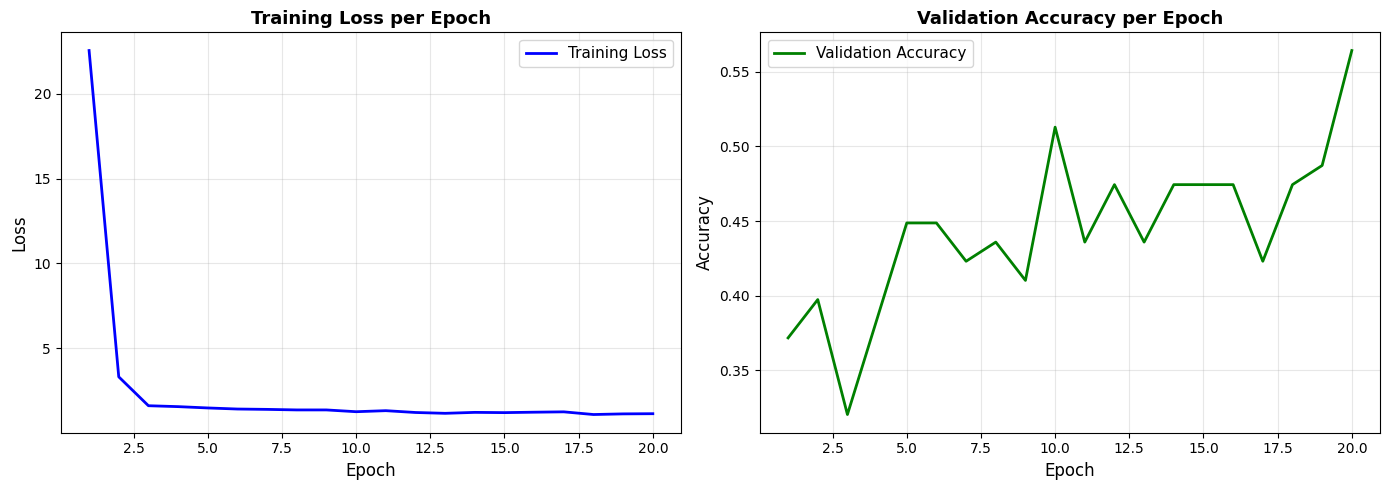

✓ Gráficas de training guardadas como 'training_curves.png'


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs +1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pérdida (Train y Val)
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.plot(epochs_range, hist_loss_val, 'r-o', label='Validation Loss')
ax1.set_title("Pérdida durante el entrenamiento y validación")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()

# Gráfico de Precisión (Train y Val)
ax2.plot(epochs_range, [a * 100 for a in hist_acc_train], 'b-o', label='Training Accuracy')
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante el entrenamiento y validación")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()

plt.tight_layout()
plt.show()

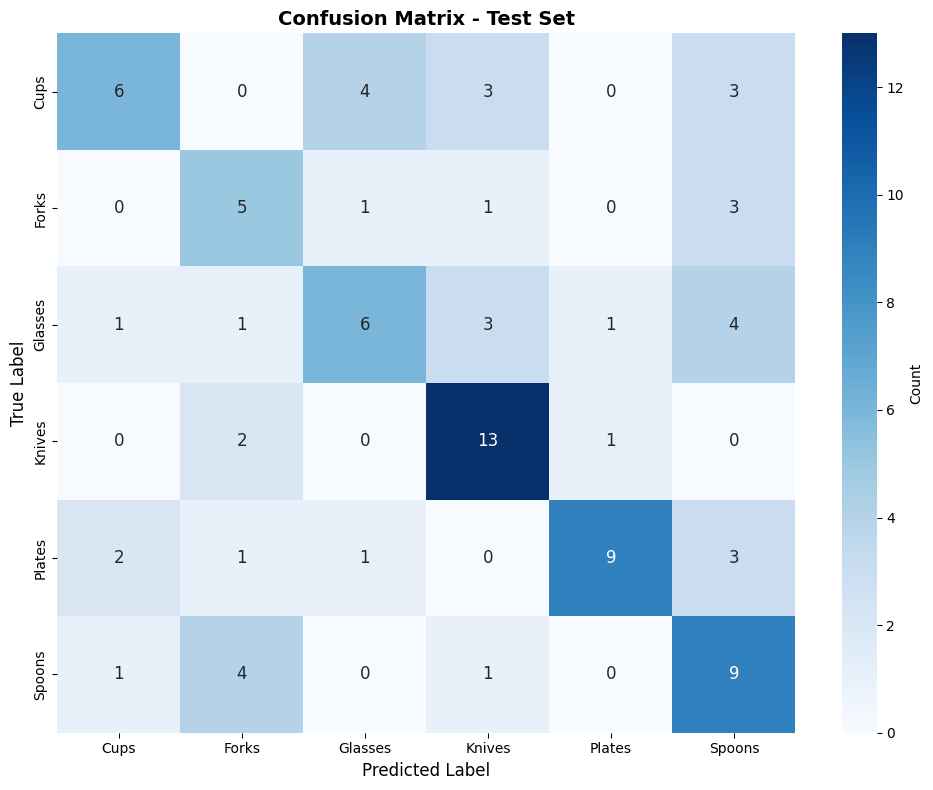

✓ Confusion Matrix guardada como 'confusion_matrix.png'


In [ ]:
# ============================================================================
# FIGURA 2: CONFUSION MATRIX
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(todas_etiquetas_test, todas_predicciones_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix guardada como 'confusion_matrix.png'")

# ── 2. IMÁGENES MAL CLASIFICADAS ─────────────────────────────────
# Buscamos índices donde la predicción fue incorrecta
errores = [(i, p, e) for i, (p, e) in enumerate(zip(todas_predicciones_test, todas_etiquetas_test)) if p != e]
print(f"\nTotal imágenes mal clasificadas: {len(errores)}")

# Mostramos las primeras 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, (i, pred, real) in enumerate(errores[:9]):
    imagen, _ = test_dataset[i]
    # Desnormalizamos para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    imagen = imagen * std[:, None, None] + mean[:, None, None]
    imagen = imagen.permute(1, 2, 0).numpy()
    imagen = np.clip(imagen, 0, 1)

    axes[idx].imshow(imagen)
    axes[idx].set_title(f'Real: {classes[real]}\nPred: {classes[pred]}', fontsize=10)
    axes[idx].axis('off')

# Ocultamos los ejes sobrantes si hay menos de 9 errores
for idx in range(len(errores[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

In [ ]:
# ============================================================================
# RESUMEN FINAL DE EXPERIMENTO 1
# ============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL - EXPERIMENTO 1")
print("="*70)

print(f"\n{'MÉTRICA':<30} {'VALIDACIÓN':<15} {'TEST':<15}")
print("-" * 60)
print(f"{'Accuracy':<30} {hist_acc_val[-1]:<15.4f} {acc_test:<15.4f}")
print(f"{'Macro F1-Score':<30}{"":<17}{f1_test:<15.4f}")
print(f"{'Training Loss (final)':<30} {hist_loss_train[-1]:<15.4f}")

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
print("✓ training_curves.png")
print("✓ confusion_matrix.png")
print("✓ misclassified.png")
print("\n✓ Experimento 1 COMPLETADO")


RESUMEN FINAL - EXPERIMENTO 1

MÉTRICA                        VALIDACIÓN      TEST           
------------------------------------------------------------
Accuracy                       0.5641          0.5393         
Macro F1-Score                 0.5493          0.5301         
Training Loss (final)          1.1432         

ARCHIVOS GENERADOS
✓ training_curves.png
✓ confusion_matrix.png

✓ Experimento 1 COMPLETADO
